In [14]:
import pandas as pd
import matplotlib.pyplot as mlp
import datetime
df = pd.read_csv('SMHI_Data.csv')
print(df)



             Datum Tid (UTC)  Lufttemperatur
0       2010-03-01  08:00:00             0.8
1       2010-03-01  09:00:00             1.0
2       2010-03-01  10:00:00             1.0
3       2010-03-01  11:00:00             0.7
4       2010-03-01  12:00:00             1.5
...            ...       ...             ...
131712  2025-01-01  02:00:00             6.0
131713  2025-01-01  03:00:00             6.1
131714  2025-01-01  04:00:00             6.4
131715  2025-01-01  05:00:00             6.5
131716  2025-01-01  06:00:00             6.7

[131717 rows x 3 columns]


0        2010-03-01 08:00:00
1        2010-03-01 09:00:00
2        2010-03-01 10:00:00
3        2010-03-01 11:00:00
4        2010-03-01 12:00:00
                 ...        
131712   2025-01-01 02:00:00
131713   2025-01-01 03:00:00
131714   2025-01-01 04:00:00
131715   2025-01-01 05:00:00
131716   2025-01-01 06:00:00
Length: 131717, dtype: datetime64[ns]


131717

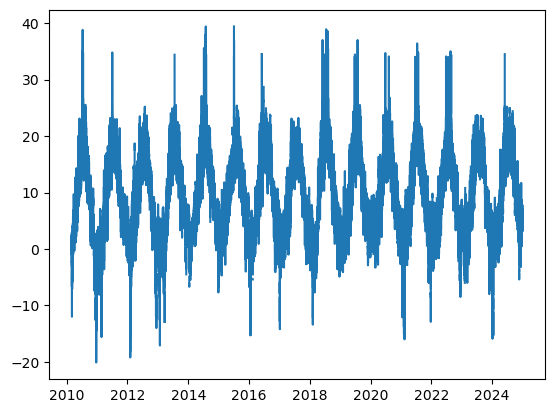

In [ ]:
x = pd.to_datetime(df["Datum"].astype(str) +" " +df["Tid (UTC)"].astype(str))
y = df["Lufttemperatur"]

mlp.plot(x,y)
len(df)


In [6]:

df_no_dupe = df.drop_duplicates()
len(df_no_dupe)

"""missing_values = df_no_dupe.isnull()
missing_list=[]
airtemp = missing_values["Lufttemperatur"]
for x in range(len(airtemp)):
    if airtemp[x]==True:
        missing_list.append(x)"""

df_no_dupe[df_no_dupe.isnull().any(axis=1)]


,Datum,Tid (UTC),Lufttemperatur
18,2010-03-02,02:00:00,NaN
46,2010-03-03,07:00:00,NaN
96,2010-03-05,10:00:00,NaN
126,2010-03-06,16:00:00,NaN
150,2010-03-07,16:00:00,NaN
...,...,...,...
131601,2024-12-27,12:00:00,NaN
131621,2024-12-28,08:00:00,NaN
131655,2024-12-29,17:00:00,NaN
131693,2024-12-31,07:00:00,NaN


                               Datum  Lufttemperatur
count                           2116     1996.000000
mean   2010-04-16 07:50:14.744801536        5.573597
min              2010-03-01 00:00:00      -12.000000
25%              2010-03-23 00:00:00        2.500000
50%              2010-04-17 00:00:00        5.900000
75%              2010-05-09 00:00:00        8.900000
max              2010-05-31 00:00:00       20.000000
std                              NaN        4.762135
          Datum Tid (UTC)  Lufttemperatur
18   2010-03-02  02:00:00             NaN
46   2010-03-03  07:00:00             NaN
96   2010-03-05  10:00:00             NaN
126  2010-03-06  16:00:00             NaN
150  2010-03-07  16:00:00             NaN
...         ...       ...             ...
2060 2010-05-28  10:00:00             NaN
2076 2010-05-29  02:00:00             NaN
2083 2010-05-29  09:00:00             NaN
2103 2010-05-30  05:00:00             NaN
2130 2010-05-31  07:00:00             NaN

[120 rows x 3 colu

5

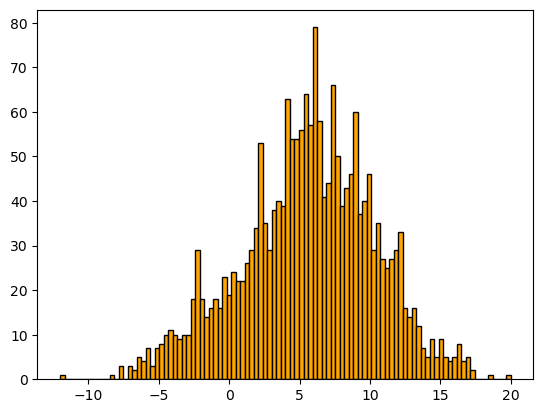

In [39]:
#KOLLA TEMPERATUR FÖR 3-MÅN INTERVALL

#print(df_no_dupe["Lufttemperatur"].max())
#print(df_no_dupe["Lufttemperatur"].min())
#print(df_no_dupe["Lufttemperatur"][:720])
limit_date = datetime.datetime(2010,6,1)
cutoff = pd.Timestamp(limit_date)
df_no_dupe["Datum"] = pd.to_datetime(df_no_dupe["Datum"])
df_monthly = df_no_dupe[df_no_dupe["Datum"]<cutoff].copy()

print(df_monthly.describe())
print(df_monthly[df_monthly.isnull().any(axis=1)])

mlp.hist(df_monthly["Lufttemperatur"], bins=100, color='orange', edgecolor='black')
3+2

5.573597194388777
4.762135458108644
                               Datum  Lufttemperatur
count                           1994     1994.000000
mean   2010-04-16 10:50:40.320963072        5.575176
min              2010-03-01 00:00:00       -8.200000
25%              2010-03-23 00:00:00        2.500000
50%              2010-04-17 00:00:00        5.900000
75%              2010-05-10 00:00:00        8.900000
max              2010-05-31 00:00:00       18.600000
std                              NaN        4.737225
 Dirty:                       Datum  Lufttemperatur
count                    2        2.000000
mean   2010-04-11 00:00:00        4.000000
min    2010-03-05 00:00:00      -12.000000
25%    2010-03-23 12:00:00       -4.000000
50%    2010-04-11 00:00:00        4.000000
75%    2010-04-29 12:00:00       12.000000
max    2010-05-18 00:00:00       20.000000
std                    NaN       22.627417
Index([91, 1813], dtype='int64')


(array([ 1.,  2.,  1.,  0.,  3.,  2.,  5.,  2.,  7.,  3.,  2.,  7.,  3.,
        13.,  8.,  9.,  6.,  9.,  6.,  9., 15., 15., 22., 18., 14.,  9.,
        15., 16., 10., 23., 19., 19., 16., 20., 13., 26., 29., 27., 34.,
        43., 18., 29., 38., 27., 36., 52., 27., 54., 54., 56., 27., 58.,
        54., 61., 58., 41., 23., 50., 55., 32., 39., 43., 30., 46., 44.,
        23., 40., 46., 19., 21., 34., 17., 25., 27., 29., 23., 17., 14.,
         9., 16.,  7.,  8.,  7.,  6.,  5.,  5.,  9.,  3.,  3.,  4.,  4.,
         8.,  4.,  2.,  3.,  2.,  0.,  0.,  0.,  1.]),
 array([-8.2  , -7.932, -7.664, -7.396, -7.128, -6.86 , -6.592, -6.324,
        -6.056, -5.788, -5.52 , -5.252, -4.984, -4.716, -4.448, -4.18 ,
        -3.912, -3.644, -3.376, -3.108, -2.84 , -2.572, -2.304, -2.036,
        -1.768, -1.5  , -1.232, -0.964, -0.696, -0.428, -0.16 ,  0.108,
         0.376,  0.644,  0.912,  1.18 ,  1.448,  1.716,  1.984,  2.252,
         2.52 ,  2.788,  3.056,  3.324,  3.592,  3.86 ,  4.128,  4.396,
  

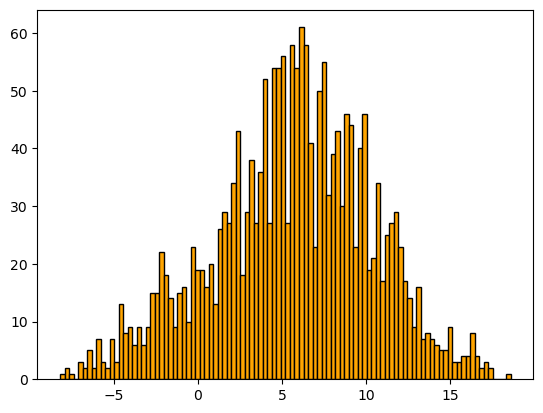

In [42]:
#DETTA TAR BORT OUTLIERS PÅ 3-MÅN PERIOD. SKA BYTA UT

monthlyMean = df_monthly["Lufttemperatur"].mean()
stdMonthly = df_monthly["Lufttemperatur"].std()
df_monthly_CLEAN = df_monthly[abs(df_monthly["Lufttemperatur"] - monthlyMean) < stdMonthly*3].copy()

df_monthly_DIRTY = df_monthly[abs(df_monthly["Lufttemperatur"] - monthlyMean) > stdMonthly*3].copy()


print(monthlyMean)
print(stdMonthly)
print(df_monthly_CLEAN.describe())

print(" Dirty: ",df_monthly_DIRTY.describe())
print(df_monthly_DIRTY.index)
#mlp.hist(df_monthly_DIRTY["Lufttemperatur"], bins=100, color='orange', edgecolor='black')
mlp.hist(df_monthly_CLEAN["Lufttemperatur"], bins=100, color='orange', edgecolor='black')